# Machine Learning Foundations: Train/Test Split, Model Fit & Linear Regression

**PKCERT AI & Software Development Internship — Task 07**

*Author: Abdullah Amir*

This notebook covers the core ML theory (train/test split, overfitting and
underfitting, the bias-variance tradeoff) and puts it into practice with a
Linear Regression model built in scikit-learn. The dataset is **Auto MPG**:
the task is to predict a car's fuel economy (`mpg`) from its specifications.

## Environment

Versions of the libraries used, which also confirms the environment is set up
with scikit-learn, pandas, numpy, and matplotlib installed.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib
import sklearn

print("Python      :", sys.version.split()[0])
print("numpy       :", np.__version__)
print("pandas      :", pd.__version__)
print("matplotlib  :", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)

Python      : 3.13.1
numpy       : 2.3.1
pandas      : 2.3.3
matplotlib  : 3.10.3
scikit-learn: 1.7.2


## Part A — Train/Test Split

### Why split the data?
A model is only useful if it works on data it has never seen. If we measured
performance on the same rows the model trained on, it could score well just by
memorising them and still fail in the real world. Splitting the data into a
**training set** (used to fit the model) and a **test set** (held back, used
only to measure performance) gives an honest estimate of how the model
generalises.

### Typical split ratios
- **80/20** is the common default and works well for medium datasets.
- **70/30** leaves a larger test set, useful when you want a more stable
  performance estimate on a smaller dataset.
- With very large datasets a smaller test fraction (like 90/10) is fine, since
  10% is still a lot of rows.

### random_state
`train_test_split` shuffles before splitting. Fixing `random_state` to a number
makes that shuffle deterministic, so the same rows land in the same set every
run. That is what makes results **reproducible** and comparisons fair.

### Validation set vs test set
A **validation set** is a third slice used *during* development to tune
hyperparameters and compare models. The **test set** is touched only once, at
the very end, for a final unbiased score. Keeping them separate stops the test
set from leaking into the tuning process.

In [2]:
from sklearn.model_selection import train_test_split

raw = pd.read_csv("mpg.csv")

# quick demo of a split on the numeric columns (full cleaning happens in Part D)
demo = raw.drop(columns=["name"]).dropna()
X_demo = demo.drop(columns=["mpg", "origin"])
y_demo = demo["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X_demo, y_demo, test_size=0.2, random_state=42)
print("Train shape:", X_train.shape, "  Test shape:", X_test.shape)

# random_state makes the split reproducible: same rows every time
a = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)[0].index
b = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)[0].index
print("Same split when random_state is fixed:", (a == b).all())

Train shape: (313, 6)   Test shape: (79, 6)
Same split when random_state is fixed: True


## Part B — Overfitting, Underfitting & the Bias-Variance Tradeoff

### Definitions
- **Underfitting:** the model is too simple to capture the real pattern, so it
  does badly on both training and test data. Example: fitting a straight line to
  data that clearly curves.
- **Overfitting:** the model is too complex and memorises noise in the training
  data, so it scores very well on training data but poorly on test data.
  Example: a high-degree polynomial that wiggles through every training point.

### Bias-variance tradeoff
- **Bias** is error from wrong assumptions (too simple a model). High bias means
  underfitting.
- **Variance** is error from being too sensitive to the training data. High
  variance means overfitting.
- As model complexity grows, bias falls but variance rises. The best model sits
  at the balance point where total error is lowest.

### Three ways to reduce overfitting
1. **Simpler model / fewer features** (lower complexity).
2. **Regularization** (Ridge/Lasso) to penalise large coefficients.
3. **Cross-validation** to catch overfitting early, and **more training data**
   when available.

### How to diagnose it
Compare training and test scores. High training score with a much lower test
score means **overfitting**. Low scores on both means **underfitting**. Close,
high scores on both means the model generalises well.

The plot below trains polynomial models of increasing degree on a single
feature (`horsepower`) and tracks training vs test error to show the tradeoff.

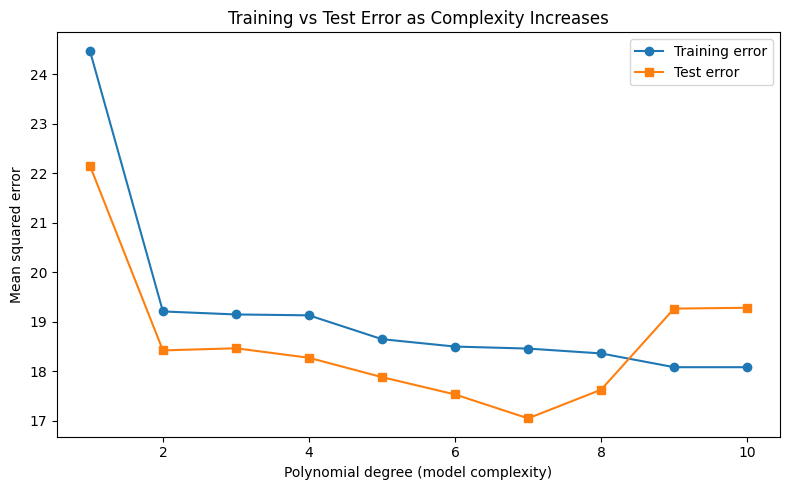

In [3]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

hp = raw.dropna(subset=["horsepower"])
Xh = hp[["horsepower"]].values
yh = hp["mpg"].values
Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(
    Xh, yh, test_size=0.2, random_state=42)

degrees = range(1, 11)
train_err, test_err = [], []
for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), StandardScaler(),
                          LinearRegression())
    model.fit(Xh_tr, yh_tr)
    train_err.append(mean_squared_error(yh_tr, model.predict(Xh_tr)))
    test_err.append(mean_squared_error(yh_te, model.predict(Xh_te)))

plt.figure(figsize=(8, 5))
plt.plot(list(degrees), train_err, "o-", label="Training error")
plt.plot(list(degrees), test_err, "s-", label="Test error")
plt.xlabel("Polynomial degree (model complexity)")
plt.ylabel("Mean squared error")
plt.title("Training vs Test Error as Complexity Increases")
plt.legend()
plt.tight_layout()
plt.savefig("figures/01_complexity_curve.png", dpi=120, bbox_inches="tight")
plt.show()

Reading left to right: at degree 1 both errors are high (**underfitting**).
Around the middle both are low, which is the sweet spot. At high degrees the
training error keeps falling while the test error shoots up, the classic sign of
**overfitting** and rising variance.

## Part C — Linear Regression: Theory & Implementation

### The maths
**Simple linear regression** fits a straight line:
$$y = m x + b$$
where `m` is the slope (how much `y` changes per unit of `x`) and `b` is the
intercept. **Multiple linear regression** extends this to many features:
$$y = b + w_1 x_1 + w_2 x_2 + \dots + w_n x_n$$

### How the coefficients are learned
The model picks the weights that minimise a **cost function**, the Mean Squared
Error between predictions and actual values:
$$J = \frac{1}{N}\sum (y_i - \hat{y}_i)^2$$
This can be solved directly with the **normal equation**
$(X^T X)^{-1} X^T y$, which is what scikit-learn's `LinearRegression` uses, or
iteratively with **gradient descent**, which nudges the weights downhill along
the gradient of the cost until it settles at the minimum.

Learned line:  mpg = -0.00781 * weight + 46.78
R2 score: 0.723


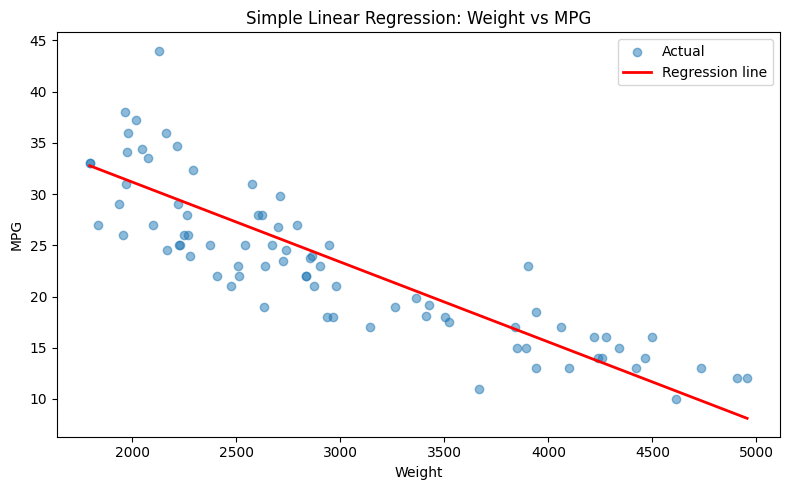

In [4]:
from sklearn.metrics import r2_score

# Simple linear regression: predict mpg from weight alone
Xw = raw[["weight"]]
yw = raw["mpg"]
Xw_tr, Xw_te, yw_tr, yw_te = train_test_split(
    Xw, yw, test_size=0.2, random_state=42)

simple = LinearRegression().fit(Xw_tr, yw_tr)
print(f"Learned line:  mpg = {simple.coef_[0]:.5f} * weight "
      f"+ {simple.intercept_:.2f}")
pred = simple.predict(Xw_te)
print(f"R2 score: {r2_score(yw_te, pred):.3f}")

plt.figure(figsize=(8, 5))
plt.scatter(Xw_te, yw_te, alpha=0.5, label="Actual")
order = np.argsort(Xw_te.values.ravel())
plt.plot(Xw_te.values.ravel()[order], pred[order], "r-", lw=2,
         label="Regression line")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.title("Simple Linear Regression: Weight vs MPG")
plt.legend()
plt.tight_layout()
plt.savefig("figures/02_regression_line.png", dpi=120, bbox_inches="tight")
plt.show()

The line slopes downward: heavier cars get fewer miles per gallon, which is
exactly what we would expect. Weight alone explains about 72% of the variation
in `mpg`.

## Part D — Practical Coding Session

### Loading and preparing the raw CSV
Here we handle the missing values (`horsepower` has 6), drop the free-text
`name` column, and one-hot encode the categorical `origin` column before
modelling.

In [5]:
def load_data(path):
    """Load the raw CSV, handle missing values, and encode categoricals."""
    df = pd.read_csv(path)
    # horsepower has 6 missing values -> fill with the median
    df["horsepower"] = df["horsepower"].fillna(df["horsepower"].median())
    # name is free text and not useful for a linear model
    df = df.drop(columns=["name"])
    # origin is categorical (usa/europe/japan) -> one-hot encode
    df = pd.get_dummies(df, columns=["origin"], drop_first=True)
    return df

data = load_data("mpg.csv")
print("Missing values after cleaning:", int(data.isnull().sum().sum()))
print("Columns:", list(data.columns))
data.head()

Missing values after cleaning: 0
Columns: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin_japan,origin_usa
0,18.0,8,307.0,130.0,3504,12.0,70,False,True
1,15.0,8,350.0,165.0,3693,11.5,70,False,True
2,18.0,8,318.0,150.0,3436,11.0,70,False,True
3,16.0,8,304.0,150.0,3433,12.0,70,False,True
4,17.0,8,302.0,140.0,3449,10.5,70,False,True


### Reusable functions
The modelling steps are refactored into small functions so they can be reused
throughout the rest of the notebook.

In [6]:
def split_data(df, target="mpg", test_size=0.2, random_state=42):
    """Split into train/test sets and print the resulting shapes."""
    X = df.drop(columns=[target])
    y = df[target]
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=test_size, random_state=random_state)
    print(f"  split {int((1-test_size)*100)}/{int(test_size*100)} -> "
          f"train {X_tr.shape}, test {X_te.shape}")
    return X_tr, X_te, y_tr, y_te


def train_model(X_train, y_train):
    """Fit and return a LinearRegression model."""
    return LinearRegression().fit(X_train, y_train)


def evaluate_model(model, X_test, y_test):
    """Return MSE and R2 for a fitted model."""
    pred = model.predict(X_test)
    return {"MSE": mean_squared_error(y_test, pred),
            "R2": r2_score(y_test, pred)}

### Full model with predicted vs actual plot

  split 80/20 -> train (318, 8), test (80, 8)
Multiple regression -> MSE: 8.34, R2: 0.845


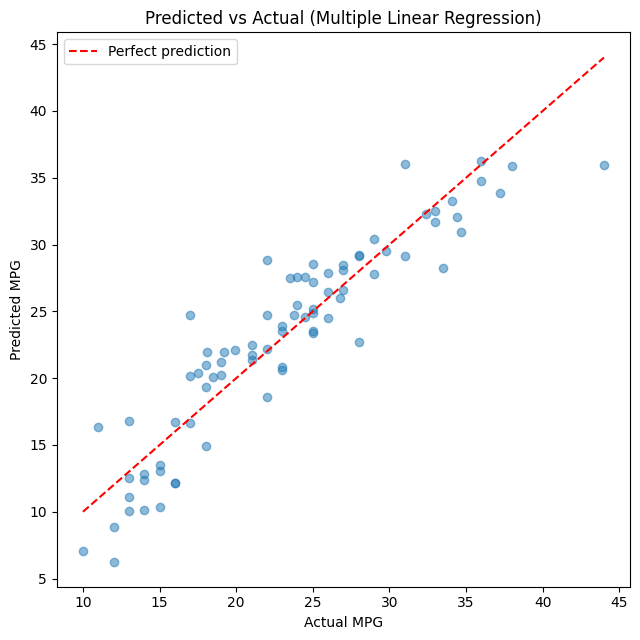

In [7]:
X_tr, X_te, y_tr, y_te = split_data(data, test_size=0.2)
model = train_model(X_tr, y_tr)
metrics = evaluate_model(model, X_te, y_te)
print(f"Multiple regression -> MSE: {metrics['MSE']:.2f}, "
      f"R2: {metrics['R2']:.3f}")

plt.figure(figsize=(6.5, 6.5))
pred = model.predict(X_te)
plt.scatter(y_te, pred, alpha=0.5)
lims = [y_te.min(), y_te.max()]
plt.plot(lims, lims, "r--", label="Perfect prediction")
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Predicted vs Actual (Multiple Linear Regression)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/03_predicted_vs_actual.png", dpi=120, bbox_inches="tight")
plt.show()

Using all the features lifts R2 to about 0.85, a clear jump over the
weight-only model. The points hug the diagonal, meaning predictions track the
real values well.

### Comparing three split ratios

In [8]:
rows = []
for ts in [0.4, 0.2, 0.1]:
    X_tr, X_te, y_tr, y_te = split_data(data, test_size=ts)
    m = train_model(X_tr, y_tr)
    r = evaluate_model(m, X_te, y_te)
    rows.append({"split": f"{int((1-ts)*100)}/{int(ts*100)}",
                 "train_rows": X_tr.shape[0], "test_rows": X_te.shape[0],
                 "MSE": round(r["MSE"], 2), "R2": round(r["R2"], 3)})

pd.DataFrame(rows)

  split 60/40 -> train (238, 8), test (160, 8)
  split 80/20 -> train (318, 8), test (80, 8)
  split 90/10 -> train (358, 8), test (40, 8)


,split,train_rows,test_rows,MSE,R2
0,60/40,238,160,9.85,0.828
1,80/20,318,80,8.34,0.845
2,90/10,358,40,10.65,0.826


The R2 stays around 0.83 to 0.85 across all three ratios, so the model is
stable and not overly sensitive to how the data is split.

### K-fold cross-validation

In [9]:
from sklearn.model_selection import cross_val_score, KFold

X = data.drop(columns=["mpg"])
y = data["mpg"]
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv = cross_val_score(LinearRegression(), X, y, cv=kf, scoring="r2")
print("Fold R2 scores:", np.round(cv, 3))
print(f"Average CV R2: {cv.mean():.3f}  (std {cv.std():.3f})")

Fold R2 scores: [0.845 0.819 0.832 0.792 0.785]
Average CV R2: 0.814  (std 0.023)


Cross-validation trains and tests on five different folds and averages the
result, giving a more trustworthy estimate than a single split. The average R2
of about 0.81 with a small spread confirms the model generalises consistently.

### Learning curve

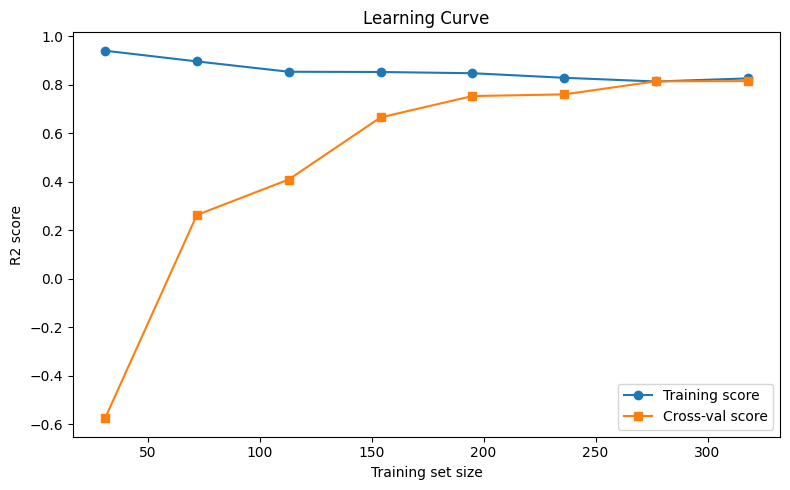

In [10]:
from sklearn.model_selection import learning_curve

sizes, train_scores, test_scores = learning_curve(
    LinearRegression(), X, y, cv=kf, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 8))

plt.figure(figsize=(8, 5))
plt.plot(sizes, train_scores.mean(axis=1), "o-", label="Training score")
plt.plot(sizes, test_scores.mean(axis=1), "s-", label="Cross-val score")
plt.xlabel("Training set size")
plt.ylabel("R2 score")
plt.title("Learning Curve")
plt.legend()
plt.tight_layout()
plt.savefig("figures/04_learning_curve.png", dpi=120, bbox_inches="tight")
plt.show()

The two curves start apart and then converge as more data is added, settling
close together at a high R2. That small final gap means the model is **not
overfitting**, and the high score means it is **not underfitting** either. It is
a well-balanced fit, and the flattening suggests much more data would give only
small gains.

## Bonus — Polynomial Regression

Here we extend the linear model with polynomial features (degrees 2 and 3) and
compare against the plain linear model to see whether the extra complexity
helps or hurts.

 degree  train_R2  test_R2
      1     0.819    0.845
      2     0.899    0.895
      3     0.954    0.076


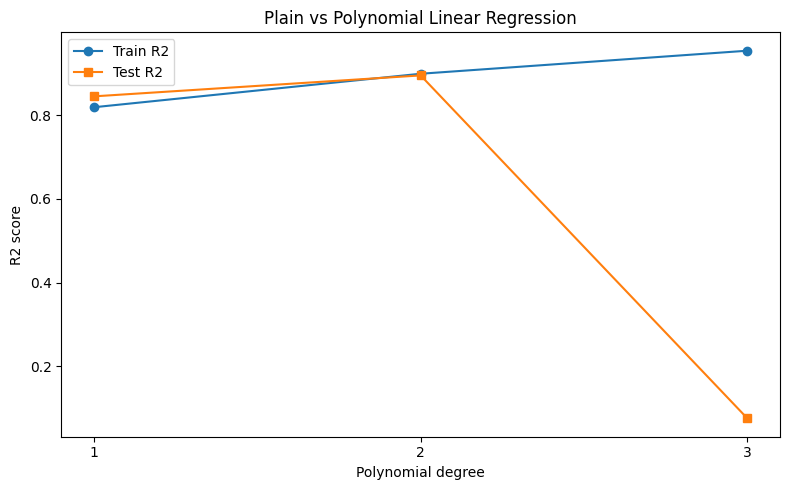

In [11]:
from sklearn.model_selection import cross_val_score

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

poly_rows = []
for d in [1, 2, 3]:
    pipe = make_pipeline(PolynomialFeatures(degree=d), StandardScaler(),
                         LinearRegression())
    pipe.fit(X_tr, y_tr)
    tr_r2 = r2_score(y_tr, pipe.predict(X_tr))
    te_r2 = r2_score(y_te, pipe.predict(X_te))
    poly_rows.append({"degree": d, "train_R2": round(tr_r2, 3),
                      "test_R2": round(te_r2, 3)})

poly_df = pd.DataFrame(poly_rows)
print(poly_df.to_string(index=False))

plt.figure(figsize=(8, 5))
plt.plot(poly_df["degree"], poly_df["train_R2"], "o-", label="Train R2")
plt.plot(poly_df["degree"], poly_df["test_R2"], "s-", label="Test R2")
plt.xticks([1, 2, 3])
plt.xlabel("Polynomial degree")
plt.ylabel("R2 score")
plt.title("Plain vs Polynomial Linear Regression")
plt.legend()
plt.tight_layout()
plt.savefig("figures/05_polynomial_comparison.png", dpi=120, bbox_inches="tight")
plt.show()

**Result.** Degree 1 (the plain linear model) scores about 0.85 on test.
Degree 2 improves it to roughly 0.90 on both train and test, so it **generalises
better**, the curved features genuinely help. Degree 3 tells the opposite story:
training R2 jumps near 0.95 but test R2 collapses to about zero (or negative).
That is textbook **overfitting**, the model has enough freedom to chase noise. So
the degree-2 model is the winner, and degree 3 is a clear warning against adding
complexity blindly.